# Gibbs chain verification

In [1]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import healpy as hp
import astropy.io.fits as fits
import camb
import scipy
import toml
import jax
import jax.numpy as jnp
import jax.lax as jlax
import jax.scipy as jsp
import jax_healpy as jhp
import numpyro
from fgbuster.observation_helpers import *
import micmac as micmac

from jax import config
config.update("jax_enable_x64", True)

In [2]:
sys.path.append(os.path.dirname(os.path.abspath('')))
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('')))+'/tutorials/')

In [3]:
working_directory_path = os.path.abspath('') + '/'
directory_save_file = working_directory_path + 'save_directory/'
directory_toml_file = working_directory_path + 'main_params/'
directory_additional_params = working_directory_path + 'additional_params/'


# Studying the sampling !

In [4]:
directory_mask_local = '/Users/mag/Documents/PHD1Y/masks/'
## #TODO: To replace with your local directory for the masks

In [5]:
list_r_values = []

file_ver_SO_r0 = 'corr_cutsky_SO_d0s0_nside0_v1091c_r0_v1db23_{}_{}'.format(0,1)
path_additional_params_SO_r0 = directory_additional_params + 'add_corr_cutsky_SO_d0s0_nside0_v1d.toml'
list_r_values.append(0)

file_ver_SO_r2 = 'corr_cutsky_SO_d0s0_nside0_v1091c_r2_v1e23_{}_{}'.format(0,1)
path_additional_params_SO_r2 = directory_additional_params + 'add_corr_cutsky_SO_d0s0_nside0_v1e.toml'
list_r_values.append(0.01)

list_file_ver = [file_ver_SO_r2, file_ver_SO_r0]
list_path_additional_params = [path_additional_params_SO_r2, path_additional_params_SO_r0]


In [6]:
MICMAC_sampler_obj_list =  []
name_mask_list = []
list_use_treshold = []
list_relative_treshold = []

for path_additional_params in list_path_additional_params:
    with open(path_additional_params) as f:
        dictionary_additional_parameters = toml.load(f)
    f.close()

    directory_mask = dictionary_additional_parameters['directory_mask']
    reduction_noise = dictionary_additional_parameters['reduction_noise']
    # factor_Fisher = dictionary_additional_parameters['factor_Fisher']
    # relative_treshold = dictionary_additional_parameters['relative_treshold']
    # sigma_gap = dictionary_additional_parameters['sigma_gap']
    fgs_model = dictionary_additional_parameters['fgs_model']
    # initial_guess_r = dictionary_additional_parameters['initial_guess_r']
    # use_nhits = dictionary_additional_parameters['use_nhits']
    use_treshold = dictionary_additional_parameters['use_treshold']
    list_use_treshold.append(use_treshold)
    relative_treshold = dictionary_additional_parameters['relative_treshold']
    list_relative_treshold.append(relative_treshold)


    # name_mask = dictionary_additional_parameters['name_mask']
    name_mask_list.append(dictionary_additional_parameters['name_mask'])

    # use_mask = dictionary_additional_parameters['use_mask']
    name_toml = dictionary_additional_parameters['name_toml']
    name_file_spv = dictionary_additional_parameters['name_file_spv']
    print("Using toml file: ", name_toml)

    path_toml_file = directory_toml_file + name_toml
    if name_file_spv != '':
        path_file_spv = directory_toml_file + name_file_spv
    else:
        path_file_spv = ''

    MICMAC_sampler_obj = micmac.create_MICMAC_sampler_from_toml_file(path_toml_file, path_file_spv)
    MICMAC_sampler_obj_list.append(MICMAC_sampler_obj)

Using toml file:  corr_cutsky_SO_r2_v1a.toml
<_io.TextIOWrapper name='/Users/mag/Documents/PHD1Y/Space_Work/Pixel_non_P2D/MICMAC/test_playground/Paper_runs_v3/main_params/params_spv_SAT_nside0.yaml' mode='r' encoding='UTF-8'>
count_b: 8
n_betas:  8

>>> Tree of spv config as passed by the User:
root
  nside_spv
    default: [0]
    f1
      default: None
      b0
        default: None
      b1
        default: None
      b2
        default: None
      b3
        default: None
    f2
      default: [0]
      b0
        default: None
      b1
        default: None
      b2
        default: None
      b3
        default: None

>>> Tree of spv config after filling the missing values:
root
  nside_spv
    default: [0]
    f1
      default: [0]
      b0
        default: [0]
      b1
        default: [0]
      b2
        default: [0]
      b3
        default: [0]
    f2
      default: [0]
      b0
        default: [0]
      b1
        default: [0]
      b2
        default: [0]
      b3
      

In [7]:
# MICMAC_sampler_obj = MICMAC_sampler_obj_list[2]
freq_inverse_noise_list = []

for MICMAC_sampler_obj in MICMAC_sampler_obj_list:
    instr_name = MICMAC_sampler_obj.instrument_name

    # get instrument from public database
    instrument = get_instrument(instr_name)

    _, _, theoretical_red_cov_r0_total, theoretical_red_cov_r1_tensor = MICMAC_sampler_obj.generate_input_freq_maps_from_fgs(np.zeros((MICMAC_sampler_obj.n_frequencies,
                                                                                                                                    MICMAC_sampler_obj.nstokes,
                                                                                                                                    MICMAC_sampler_obj.n_pix,)), 
                                                                                                                            return_only_freq_maps=False)

    freq_inverse_noise_list.append(micmac.get_noise_covar_extended(instrument['depth_p'], MICMAC_sampler_obj.nside))

Calculating spectra from CAMB !
Calculating spectra from CAMB !
Calculating spectra from CAMB !
Calculating spectra from CAMB !


In [8]:
initial_freq_maps = []
input_cmb_maps = []
input_noise_map = []
all_eta_maps = []
all_s_c_WF_maps = []
all_s_c_fluct_maps = []
all_s_c_samples = []
all_r_samples = []
all_cell_samples = []
all_params_mixing_matrix_samples = []

for file_ver in list_file_ver:
# job = 0
# num_jobs = 1
# initial_freq_maps_path = directory_save_file+file_ver.format(job,num_jobs)+'_initial_data.npy'
    initial_freq_maps_path = directory_save_file+file_ver+'_initial_data.npy'
    # initial_freq_maps = np.load(initial_freq_maps_path)
    initial_freq_maps.append(np.load(initial_freq_maps_path))

    initial_noise_map_path = directory_save_file+file_ver+'_initial_noise_data.npy'
    # input_noise_map = np.load(initial_noise_map_path)
    input_noise_map.append(np.load(initial_noise_map_path))

    # initial_cmb_maps_path = directory_save_file+file_ver.format(job,num_jobs)+'_initial_cmb_data.npy'
    initial_cmb_maps_path = directory_save_file+file_ver+'_initial_cmb_data.npy'
    # input_cmb_maps = np.load(initial_cmb_maps_path)
    input_cmb_maps.append(np.load(initial_cmb_maps_path))

    if MICMAC_sampler_obj.sample_r_Metropolis:
        # all_r_samples_path = directory_save_file+file_ver.format(job,num_jobs)+'_all_r_samples.npy'
        all_r_samples_path = directory_save_file+file_ver+'_all_r_samples.npy'
        # all_r_samples = np.load(all_r_samples_path)
        all_r_samples.append(np.load(all_r_samples_path))
    elif MICMAC_sampler_obj.sample_C_inv_Wishart:
        # all_cell_samples_path = directory_save_file+file_ver.format(job,num_jobs)+'_all_cell_samples.npy'
        all_cell_samples_path = directory_save_file+file_ver+'_all_cell_samples.npy'
        # all_cell_samples = np.load(all_cell_samples_path)
        all_cell_samples.append(np.load(all_cell_samples_path))

    # all_params_mixing_matrix_samples_path = directory_save_file+file_ver.format(job,num_jobs)+'_all_params_mixing_matrix_samples.npy'
    all_params_mixing_matrix_samples_path = directory_save_file+file_ver+'_all_params_mixing_matrix_samples.npy'
    # all_params_mixing_matrix_samples = np.load(all_params_mixing_matrix_samples_path)
    all_params_mixing_matrix_samples.append(np.load(all_params_mixing_matrix_samples_path))


In [9]:
n_correl_to_plot = int(np.ceil(MICMAC_sampler_obj.nstokes**2/2) + np.floor(MICMAC_sampler_obj.nstokes/2))

if MICMAC_sampler_obj.nstokes == 3:
    number_subplots_convention = 421
    figsize = (10,10)
    figsize_big = (12,12)
    position_legend = int(n_correl_to_plot/2)-1
    bbox_to_anchor=(2.2, 1)
elif MICMAC_sampler_obj.nstokes == 2:
    number_subplots_convention = 131
    figsize = (14,6)
    figsize_big = figsize
    position_legend = n_correl_to_plot-1
    bbox_to_anchor=(1, 1)
else:
    number_subplots_convention = 111
    figsize = (10,10)
    figsize_big = (10,10)
    position_legend = int(n_correl_to_plot/2)-1
    bbox_to_anchor=(2.2, 1)

## Handling mask

f_sky =  0.10715738932291667


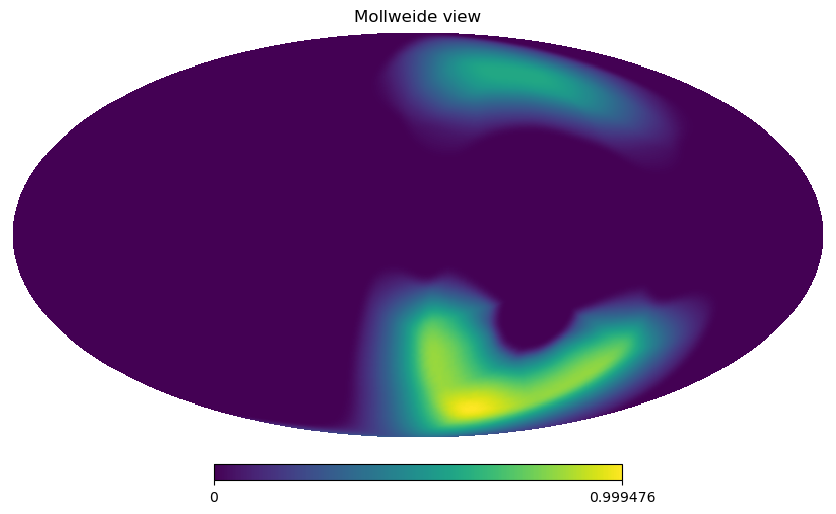

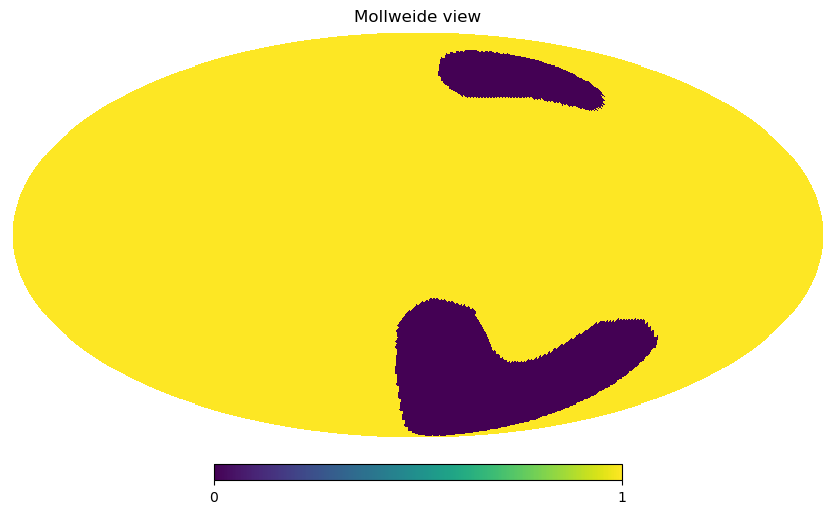

f_sky =  0.10715738932291667


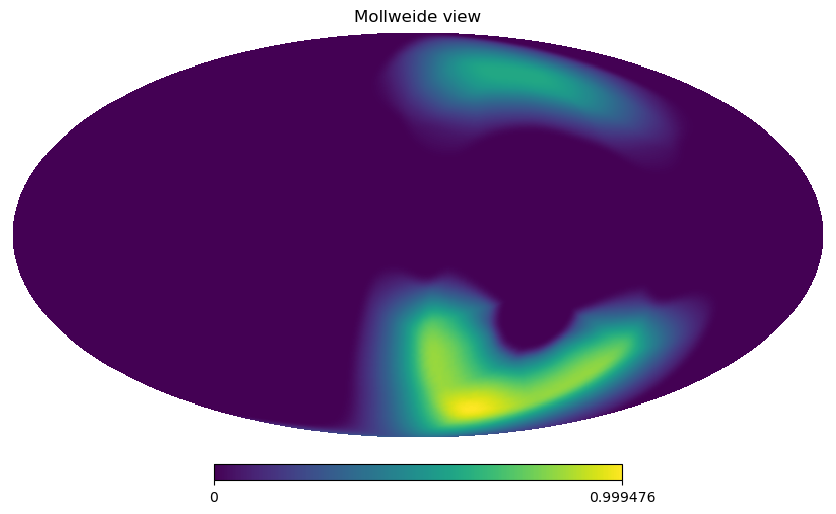

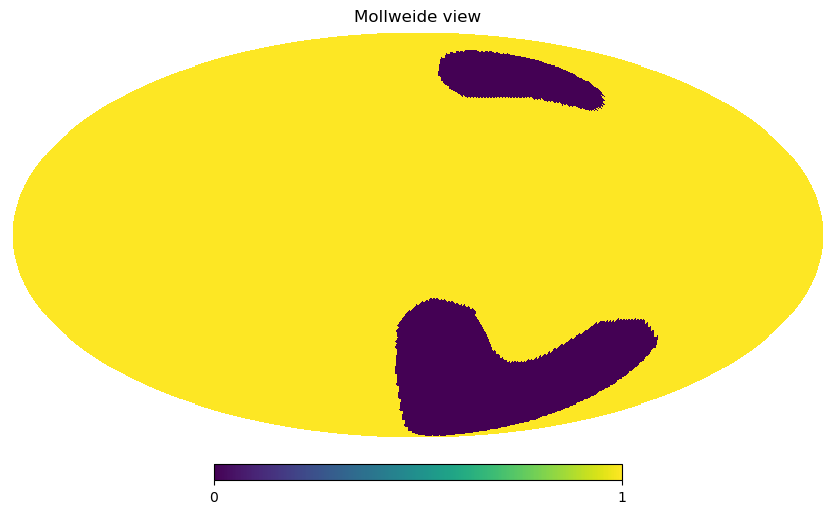

In [10]:
for i in range(len(name_mask_list)):
    name_mask = name_mask_list[i]
    MICMAC_sampler_obj = MICMAC_sampler_obj_list[i]
    relative_treshold = list_relative_treshold[i]
    use_treshold = list_use_treshold[i]

    path_mask = directory_mask_local + name_mask + '.fits'

    if os.path.exists(path_mask):
        mask = hp.read_map(path_mask, verbose=False)

        hp.mollview(mask)

        mask_apod = hp.ud_grade(mask, nside_out=MICMAC_sampler_obj.nside, dtype=np.float64)

        mask = np.zeros_like(mask_apod, dtype=np.int64)
        if use_treshold:
            mask[mask_apod > relative_treshold] = 1
        else:
            mask[mask_apod > 0] = 1

        MICMAC_sampler_obj.mask = mask

        if MICMAC_sampler_obj.indexes_b.size != 1: 
        # if MICMAC_sampler_obj.size_patches.max() > 1:
            frequency_Bf = np.array(instrument['frequency'][1:-1])
            number_free_Bf = (MICMAC_sampler_obj.n_frequencies-len(MICMAC_sampler_obj.pos_special_freqs))*(MICMAC_sampler_obj.n_components - 1)
            extended_array = np.zeros((number_free_Bf+1),dtype=np.int64)
            extended_array[:-1] = MICMAC_sampler_obj.indexes_b.ravel(order='F')
            extended_array[-1] = extended_array[:-1].max() + MICMAC_sampler_obj.size_patches[-1]
            
            all_templates = MICMAC_sampler_obj.get_all_templates()%MICMAC_sampler_obj.size_patches[-1] + 1
            # for i in range(number_free_Bf):
            #     freq = i//(MICMAC_sampler_obj.n_components - 1)
            #     comp = i%(MICMAC_sampler_obj.n_components - 1)
            hp.mollview(all_templates[0,0] - all_templates[0,0]*mask)
        
        print("f_sky = ", mask.sum()/mask.size)
        plt.show()

    else:
        print("Mask not found")
        mask = np.ones(hp.nside2npix(NSIDE), dtype=np.int64)
        MICMAC_sampler_obj.mask = mask

In [11]:
c_ell_true_CMB = micmac.get_c_ells_from_red_covariance_matrix_JAX(theoretical_red_cov_r0_total + MICMAC_sampler_obj.r_true*theoretical_red_cov_r1_tensor)
c_ell_CMB_r2 = micmac.get_c_ells_from_red_covariance_matrix_JAX(theoretical_red_cov_r0_total + 0.01*theoretical_red_cov_r1_tensor)
c_ell_lensing = micmac.get_c_ells_from_red_covariance_matrix_JAX(theoretical_red_cov_r0_total)

In [12]:
f_sky_list = []
for MICMAC_sampler_obj in MICMAC_sampler_obj_list:
    f_sky_list.append(MICMAC_sampler_obj.mask.sum()/MICMAC_sampler_obj.mask.size)

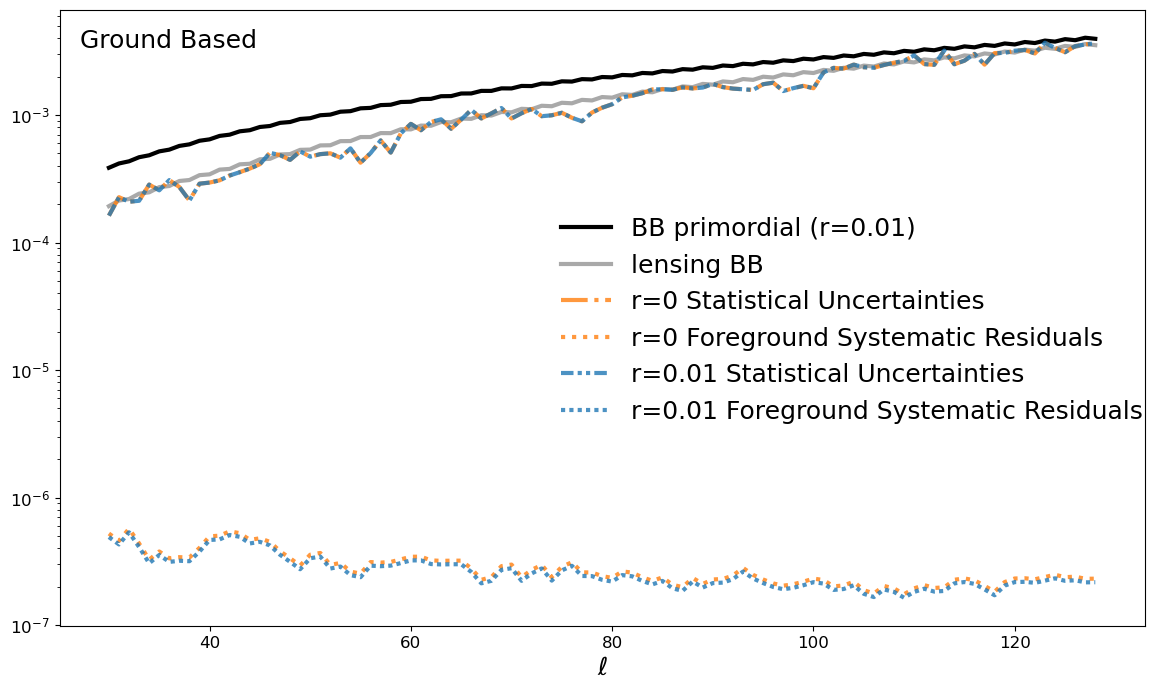

In [26]:
# Residuals power spectrum

# new_range_iterations = range_iterations
burnin = 8000

colorstyle_list = ['tab:orange','tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown','tab:pink','tab:gray','tab:olive','tab:cyan']

indices_polar = np.array([1,2,4])

linewidth_plots = 3

# fig = plt.figure(figsize=(14,8))
fig, axes = plt.subplots(figsize=(14,8))

# lmin_LB = 2
# lmin_S0 = 30 - lmin_LB

ell_array = np.arange(c_ell_true_CMB.shape[-1]) + MICMAC_sampler_obj.lmin

factor_ell = (ell_array*(ell_array+1))/(2*np.pi)

plt.plot(ell_array, c_ell_CMB_r2[1,:]*factor_ell, 'k', linewidth=linewidth_plots, label='BB primordial (r=0.01)')
plt.plot(ell_array, c_ell_lensing[1,:]*factor_ell, color='darkgray', linewidth=linewidth_plots, label='lensing BB')

r_value_covered = set()

for i in range(len(MICMAC_sampler_obj_list)):
    mean_params = all_params_mixing_matrix_samples[i][-burnin:].mean(axis=0)

    MICMAC_sampler_obj = MICMAC_sampler_obj_list[i]
    freq_inverse_noise = freq_inverse_noise_list[i]
    f_sky = f_sky_list[i]

    mean_mixing_matrix = MICMAC_sampler_obj.get_B_from_params(mean_params)
    recovered_CMB_Wd_mean = micmac.get_Wd(freq_inverse_noise, 
                                            mean_mixing_matrix, 
                                            (initial_freq_maps[i]-input_cmb_maps[i]-input_noise_map[i])*MICMAC_sampler_obj.mask, 
                                            jax_use=False)[0, :, :]
    recovered_res_wo_CMB_mean = micmac.get_Wd(freq_inverse_noise, 
                                                mean_mixing_matrix, 
                                                initial_freq_maps[i]*MICMAC_sampler_obj.mask, 
                                                jax_use=False)[0, :, :] - input_cmb_maps[i][0]*MICMAC_sampler_obj.mask
    recovered_CMB_Wd_mean_extended = np.vstack([np.zeros_like(recovered_CMB_Wd_mean[0]), recovered_CMB_Wd_mean])
    c_ells_recovered_CMB_Wd_mean = hp.anafast(recovered_CMB_Wd_mean_extended, lmax=MICMAC_sampler_obj.lmax, iter=MICMAC_sampler_obj.n_iter)[2,MICMAC_sampler_obj.lmin:]/f_sky
    recovered_res_wo_CMB_mean_extended = np.vstack([np.zeros_like(recovered_res_wo_CMB_mean[0]), recovered_res_wo_CMB_mean])
    c_ells_recovered_res_wo_CMB_mean = hp.anafast(recovered_res_wo_CMB_mean_extended, lmax=MICMAC_sampler_obj.lmax, iter=MICMAC_sampler_obj.n_iter)[2,MICMAC_sampler_obj.lmin:]/f_sky

    ell_array = np.arange(c_ells_recovered_CMB_Wd_mean.shape[-1])+MICMAC_sampler_obj.lmin

    factor_ell = (ell_array*(ell_array+1))/(2*np.pi)


    # label_Stat_res = f"{MICMAC_sampler_obj.instrument_name} r={list_r_values[i]} ; Statistical Residuals"
    if list_r_values[i] not in r_value_covered:
        label_Stat_res = f"r={list_r_values[i]} Statistical Uncertainties"
        label_Syst_res = f'r={list_r_values[i]} Foreground Systematic Residuals'
        r_value_covered.add(list_r_values[i])
    else:
        label_Stat_res = None
        label_Syst_res = None
    linestyle_dashdotted = '-.'
    if list_r_values[i] == 0.01:
        linestyle_dashdotted = (0, (3, 1, 1, 1, 1, 1))
    plt.plot(ell_array, 
                (c_ells_recovered_res_wo_CMB_mean-c_ells_recovered_CMB_Wd_mean)*factor_ell,
                linestyle=linestyle_dashdotted,
                linewidth=linewidth_plots,
                color=colorstyle_list[i], 
                label=label_Stat_res, alpha=.8)

    linestyle_dotted = ':'
    if list_r_values[i] == 0.01:
        linestyle_dotted = (0, (1, 1))
    plt.plot(ell_array, 
                c_ells_recovered_CMB_Wd_mean*factor_ell, 
                linestyle=linestyle_dotted,
                linewidth=linewidth_plots, 
                color=colorstyle_list[i], 
                label=label_Syst_res, alpha=.8)

    if MICMAC_sampler_obj.instrument_name == 'LiteBIRD':
        plt.loglog()
    else:
        plt.yscale('log')
    if i == 2:
        plt.set_ylabel("$D^{BB}_\ell$ [$uK^2$]",fontsize=18)
    plt.xlabel(r"$\ell$",fontsize=18)
    plt.tick_params(axis='both', which='major', labelsize=12)
    plt.tick_params(axis='both', which='minor', labelsize=12)
    
    
# plt.text(.13, .97, 'Satellite', 
#                         horizontalalignment='center', 
#                         verticalalignment='center', 
#                         fontsize=18, 
#                         transform=axes['a'].transAxes)
plt.text(.1, .95, 'Ground Based', 
                        horizontalalignment='center', 
                        verticalalignment='center', 
                        fontsize=18, 
                        transform=axes.transAxes)
# handles_a, labels_a = axes['a'].get_legend_handles_labels()
# handles_b, labels_b = axes['b'].get_legend_handles_labels()
# fig.legend(handles_b+handles_a, labels_b+labels_a, bbox_to_anchor=(.73, .45), loc='upper center', prop={'size': 18}, frameon=False)

plt.legend(bbox_to_anchor=(.73, .7), loc='upper center', prop={'size': 18}, frameon=False)
plt.show()


In [88]:
new_range_iterations_to_use = 8000 #10000 #8076

for i in range(len(MICMAC_sampler_obj_list)):

    sorted_r_samples = np.sort(all_r_samples[i][-new_range_iterations_to_use:])

    number_samples_to_keep = int(new_range_iterations_to_use*.95)

    mean_95CL = np.mean(sorted_r_samples[:number_samples_to_keep])
    std_95CL = np.std(sorted_r_samples[:number_samples_to_keep])
    max_95CL = np.max(sorted_r_samples[:number_samples_to_keep])
    true_max = sorted_r_samples[-1]

    print(f"r={list_r_values[i]}: 95% CL mean={mean_95CL} std={std_95CL} max={max_95CL}, true max={true_max}")
    

r=0: 95% CL mean=0.009973384478745963 std=0.0017293602217306645 max=0.013700747758717262, true max=0.01626314653327184
r=0.01: 95% CL mean=-0.0001222713735730512 std=0.0011235670396089143 max=0.0019962578971621753, true max=0.004983917659711849
r=0: 95% CL mean=2.7849364316851505e-05 std=7.432647870068333e-05 max=0.00020696796225254166, true max=0.00043256357680539654
